In [1]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.metrics.pairwise import cosine_similarity

import torch

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

In [3]:
ratings = pd.read_csv(
    "data/ml-100k/u.data",
    sep="\t",
    names=["user_id", "item_id", "rating", "timestamp"]
)

ratings.head()

,user_id,item_id,rating,timestamp
0,196,242,3,881250949
1,186,302,3,891717742
2,22,377,1,878887116
3,244,51,2,880606923
4,166,346,1,886397596


In [4]:
print("Ratings:", len(ratings))
print("Users:", ratings["user_id"].nunique())
print("Movies:", ratings["item_id"].nunique())

Ratings: 100000
Users: 943
Movies: 1682


In [5]:
train_parts = []
val_parts = []
test_parts = []

for user_id, group in ratings.groupby("user_id"):
    
    group = group.sample(frac=1, random_state=SEED)
    
    n = len(group)
    n_train = int(n * 0.8)
    n_val = int(n * 0.1)

    train_parts.append(group.iloc[:n_train])
    val_parts.append(group.iloc[n_train:n_train+n_val])
    test_parts.append(group.iloc[n_train+n_val:])

train_df = pd.concat(train_parts).reset_index(drop=True)
val_df = pd.concat(val_parts).reset_index(drop=True)
test_df = pd.concat(test_parts).reset_index(drop=True)

print(len(train_df), len(val_df), len(test_df))

79619 9596 10785


In [6]:
user_item_matrix = train_df.pivot_table(
    index="user_id",
    columns="item_id",
    values="rating"
)

user_item_matrix.shape

(943, 1655)

In [7]:
## Memory - based CF

similarity_matrix = cosine_similarity(
    user_item_matrix.fillna(0)
)

similarity_matrix = pd.DataFrame(
    similarity_matrix,
    index=user_item_matrix.index,
    columns=user_item_matrix.index
)

In [8]:
def predict_memory(user_id, item_id, k=40):

    if item_id not in user_item_matrix.columns:
        return train_df["rating"].mean()

    sims = similarity_matrix.loc[user_id].drop(user_id)

    neighbors = sims.sort_values(ascending=False).head(k)

    ratings = user_item_matrix.loc[
        neighbors.index, item_id
    ].dropna()

    if len(ratings) == 0:
        return train_df["rating"].mean()

    weights = neighbors.loc[ratings.index]

    prediction = np.average(
        ratings,
        weights=weights
    )

    return np.clip(prediction, 1, 5)

In [9]:
predictions = []
actual = []

for _, row in test_df.iterrows():

    pred = predict_memory(
        row["user_id"],
        row["item_id"],
        k=40
    )

    predictions.append(pred)
    actual.append(row["rating"])

In [12]:
memory_mae = mean_absolute_error(actual, predictions)

memory_rmse = np.sqrt(
    mean_squared_error(actual, predictions)
)

print("Memory-Based CF")
print("----------------")
print(f"MAE  : {memory_mae:.4f}")
print(f"RMSE : {memory_rmse:.4f}")

Memory-Based CF
----------------
MAE  : 0.8285
RMSE : 1.0502


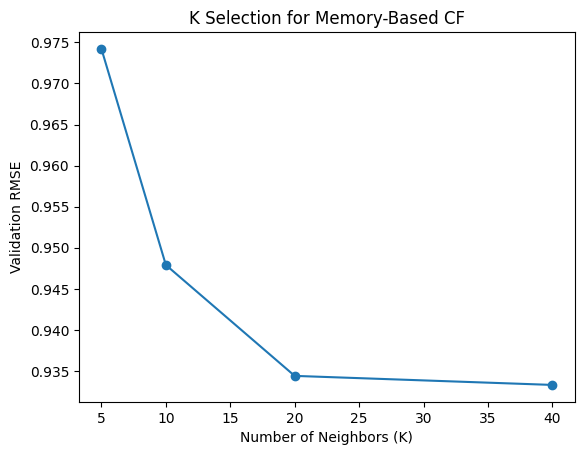

In [13]:
k_values = [5, 10, 20, 40]
rmse_values = [0.9742, 0.9479, 0.9344, 0.9333]

plt.plot(k_values, rmse_values, marker="o")
plt.xlabel("Number of Neighbors (K)")
plt.ylabel("Validation RMSE")
plt.title("K Selection for Memory-Based CF")
plt.show()

In [24]:
class MatrixFactorization(torch.nn.Module):

    def __init__(self, n_users, n_items, k=32):
        super().__init__()

        self.user_embedding = torch.nn.Embedding(
            n_users, k
        )

        self.item_embedding = torch.nn.Embedding(
            n_items, k
        )

        self.user_bias = torch.nn.Embedding(
            n_users, 1
        )

        self.item_bias = torch.nn.Embedding(
            n_items, 1
        )

        self.global_bias = torch.nn.Parameter(
            torch.tensor(0.0)
        )

    def forward(self, users, items):

        user_emb = self.user_embedding(users)
        item_emb = self.item_embedding(items)

        interaction = (
            user_emb * item_emb
        ).sum(dim=1)

        prediction = (
            interaction
            + self.user_bias(users).squeeze()
            + self.item_bias(items).squeeze()
            + self.global_bias
        )

        return prediction

In [25]:
users = train_df["user_id"].unique()
items = train_df["item_id"].unique()

user_to_idx = {
    u: i for i, u in enumerate(users)
}

item_to_idx = {
    item: i for i, item in enumerate(items)
}

n_users = len(users)
n_items = len(items)

In [26]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

model = MatrixFactorization(
    n_users,
    n_items,
    k=32
).to(device)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.005,
    weight_decay=0.0001
)

loss_fn = torch.nn.MSELoss()

Device: cpu


In [27]:
train_users = torch.tensor(
    [user_to_idx[u] for u in train_df["user_id"]],
    dtype=torch.long
)

train_items = torch.tensor(
    [item_to_idx[i] for i in train_df["item_id"]],
    dtype=torch.long
)

train_ratings = torch.tensor(
    train_df["rating"].values,
    dtype=torch.float32
)

In [28]:
from torch.utils.data import TensorDataset, DataLoader

train_dataset = TensorDataset(
    train_users,
    train_items,
    train_ratings
)

train_loader = DataLoader(
    train_dataset,
    batch_size=2048,
    shuffle=True
)

In [29]:
val_valid = val_df[
    val_df["user_id"].isin(user_to_idx) &
    val_df["item_id"].isin(item_to_idx)
].copy()

val_users = torch.tensor(
    [user_to_idx[u] for u in val_valid["user_id"]],
    dtype=torch.long
)

val_items = torch.tensor(
    [item_to_idx[i] for i in val_valid["item_id"]],
    dtype=torch.long
)

val_ratings = torch.tensor(
    val_valid["rating"].values,
    dtype=torch.float32
)

In [38]:
mf_history = []
val_rmse_history = []

best_val_rmse = float("inf")
best_state = None

epochs = 50

for epoch in range(epochs):

    model.train()

    total_loss = 0.0

    for batch_users, batch_items, batch_ratings in train_loader:

        batch_users = batch_users.to(device)
        batch_items = batch_items.to(device)
        batch_ratings = batch_ratings.to(device)

        optimizer.zero_grad()

        predictions = model(
            batch_users,
            batch_items
        )

        loss = loss_fn(
            predictions,
            batch_ratings
        )

        loss.backward()
        optimizer.step()

        total_loss += loss.item() * len(batch_ratings)

    train_loss = total_loss / len(train_dataset)

    # Validation
    model.eval()

    with torch.no_grad():

        val_pred = model(
            val_users.to(device),
            val_items.to(device)
        ).cpu().numpy()

    val_pred = np.clip(val_pred, 1, 5)

    val_rmse = np.sqrt(
        mean_squared_error(
            val_valid["rating"].values,
            val_pred
        )
    )

    mf_history.append(train_loss)
    val_rmse_history.append(val_rmse)

    print(
        f"Epoch {epoch+1:02d}/{epochs} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val RMSE: {val_rmse:.4f}"
    )

    # Save best model
    if val_rmse < best_val_rmse:

        best_val_rmse = val_rmse

        best_state = {
            key: value.cpu().clone()
            for key, value in model.state_dict().items()
        }

print("\nBest Validation RMSE:", round(best_val_rmse, 4))

Epoch 01/50 | Train Loss: 0.9711 | Val RMSE: 1.4198
Epoch 02/50 | Train Loss: 0.9274 | Val RMSE: 1.4024
Epoch 03/50 | Train Loss: 0.8882 | Val RMSE: 1.3863
Epoch 04/50 | Train Loss: 0.8529 | Val RMSE: 1.3705
Epoch 05/50 | Train Loss: 0.8211 | Val RMSE: 1.3556
Epoch 06/50 | Train Loss: 0.7924 | Val RMSE: 1.3409
Epoch 07/50 | Train Loss: 0.7662 | Val RMSE: 1.3270
Epoch 08/50 | Train Loss: 0.7424 | Val RMSE: 1.3134
Epoch 09/50 | Train Loss: 0.7210 | Val RMSE: 1.3006
Epoch 10/50 | Train Loss: 0.7013 | Val RMSE: 1.2878
Epoch 11/50 | Train Loss: 0.6833 | Val RMSE: 1.2760
Epoch 12/50 | Train Loss: 0.6667 | Val RMSE: 1.2642
Epoch 13/50 | Train Loss: 0.6515 | Val RMSE: 1.2529
Epoch 14/50 | Train Loss: 0.6374 | Val RMSE: 1.2423
Epoch 15/50 | Train Loss: 0.6244 | Val RMSE: 1.2321
Epoch 16/50 | Train Loss: 0.6123 | Val RMSE: 1.2218
Epoch 17/50 | Train Loss: 0.6012 | Val RMSE: 1.2125
Epoch 18/50 | Train Loss: 0.5907 | Val RMSE: 1.2032
Epoch 19/50 | Train Loss: 0.5809 | Val RMSE: 1.1944
Epoch 20/50 

In [39]:
model.load_state_dict(best_state)

model = model.to(device)

print(
    "Best model restored."
)

print(
    "Best Validation RMSE:",
    round(best_val_rmse, 4)
)

Best model restored.
Best Validation RMSE: 1.035


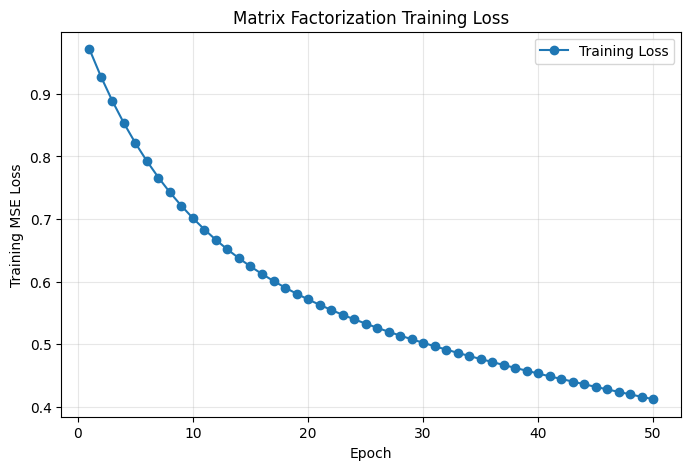

In [40]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, epochs + 1),
    mf_history,
    marker="o",
    label="Training Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Training MSE Loss")
plt.title("Matrix Factorization Training Loss")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [41]:
model.eval()

test_valid = test_df[
    test_df["user_id"].isin(user_to_idx) &
    test_df["item_id"].isin(item_to_idx)
].copy()

test_users = torch.tensor(
    [user_to_idx[u] for u in test_valid["user_id"]],
    dtype=torch.long
).to(device)

test_items = torch.tensor(
    [item_to_idx[i] for i in test_valid["item_id"]],
    dtype=torch.long
).to(device)

with torch.no_grad():

    mf_predictions = model(
        test_users,
        test_items
    ).cpu().numpy()

mf_predictions = np.clip(
    mf_predictions,
    1,
    5
)

mf_actual = test_valid["rating"].values

In [42]:
mf_mae = mean_absolute_error(
    mf_actual,
    mf_predictions
)

mf_rmse = np.sqrt(
    mean_squared_error(
        mf_actual,
        mf_predictions
    )
)

print("Matrix Factorization")
print("---------------------")
print(f"MAE  : {mf_mae:.4f}")
print(f"RMSE : {mf_rmse:.4f}")

Matrix Factorization
---------------------
MAE  : 0.8178
RMSE : 1.0494


In [43]:
results = pd.DataFrame({
    "Model": [
        "Memory-Based CF",
        "Matrix Factorization"
    ],
    "MAE": [
        memory_mae,
        mf_mae
    ],
    "RMSE": [
        memory_rmse,
        mf_rmse
    ]
})

results.round(4)

,Model,MAE,RMSE
0,Memory-Based CF,0.8285,1.0502
1,Matrix Factorization,0.8178,1.0494


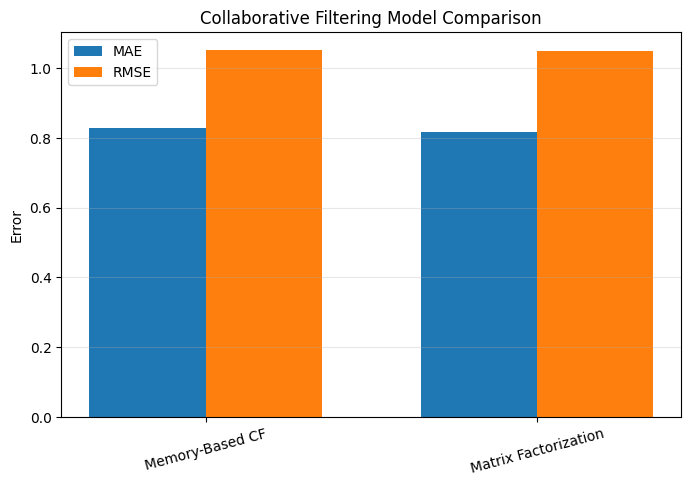

In [44]:
x = np.arange(len(results))
width = 0.35

plt.figure(figsize=(8, 5))

plt.bar(
    x - width/2,
    results["MAE"],
    width,
    label="MAE"
)

plt.bar(
    x + width/2,
    results["RMSE"],
    width,
    label="RMSE"
)

plt.xticks(
    x,
    results["Model"],
    rotation=15
)

plt.ylabel("Error")
plt.title("Collaborative Filtering Model Comparison")
plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.show()